In [ ]:
from google.colab import drive
drive.mount('/content/drive')  
SAVE_DIR = "/content/drive/MyDrive/Det_Seg/save_models"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Det_Seg
!pip install ultralytics

import cv2, numpy as np, torch
from ultralytics import YOLO


/content/drive/MyDrive/Det_Seg


In [ ]:
DET_WEIGHTS = "/content/drive/MyDrive/Group_Project/runs/detect/train9/weights/best.pt"  # detection model 
SEG_WEIGHTS = "/content/drive/MyDrive/Segmentation/runs/segment/train/weights/best.pt" # segmentation model 
SOURCE      = "/content/drive/MyDrive/Det_Seg/download.jpg"  

IMG_SIZE   = 640        
ROI_RATIO  = 0.40       
INFLATE_PX = 31         
SHOW       = True       

DET_CLASS_WHITELIST = None      
SEG_CLASS_WHITELIST = None      


In [ ]:
def draw_overlay(frame, danger_mask, color=(0, 0, 255), alpha=0.5):
    """
    frame: BGR uint8 (H,W,3)
    danger_mask: uint8 (H,W), 0/255 hoặc bool
    """
    if danger_mask.ndim == 3:
        
        danger_mask = (danger_mask[...,0] | danger_mask[...,1] | danger_mask[...,2]).astype(np.uint8)

    m = (danger_mask > 0)  # 2D boolean mask HxW
    overlay = frame.copy()
    
    overlay[m] = (alpha * overlay[m] + (1 - alpha) * np.array(color, dtype=np.float32)).astype(np.uint8)
   
    return cv2.addWeighted(overlay, 0.7, frame, 0.3, 0)

def side_summary(mask):
    H, W = mask.shape
    thirds = [0, W//3, 2*W//3, W]
    sides = ["trái","giữa","phải"]
    counts, flagged = [], []
    for i in range(3):
        m = mask[:, thirds[i]:thirds[i+1]]
        c = int((m>0).sum()); counts.append(c)
        if c > 0: flagged.append(sides[i])
    return flagged, counts

def to_np(x):
    if isinstance(x, torch.Tensor): return x.detach().cpu().numpy()
    return np.array(x)

In [ ]:
det_model = YOLO(DET_WEIGHTS)   # detect weights
seg_model = YOLO(SEG_WEIGHTS)   # segmentation weights  
# Results fields: boxes.xyxy / boxes.cls / boxes.conf / masks.data / names … :contentReference[oaicite:1]{index=1}

In [ ]:

is_stream = isinstance(SOURCE, int) or (isinstance(SOURCE, str) and SOURCE.lower().endswith((".mp4",".avi",".mov",".mkv")))
cap = cv2.VideoCapture(SOURCE) if is_stream else None

def which_side(xc, W):
    
    if xc < W/3: return "trái"
    if xc < 2*W/3: return "giữa"
    return "phải"

def process_frame(img):
    # 1) Run models
    det_res = det_model.predict(img, imgsz=IMG_SIZE, verbose=False)[0]
    seg_res = seg_model.predict(img, imgsz=IMG_SIZE, verbose=False)[0]

    # 2) Size of original image
    H, W = seg_res.orig_img.shape[:2]
    y0 = int(H*(1.0-ROI_RATIO))  

    # Segmentation
    seg_items = []
    danger_seg = np.zeros((H, W), np.uint8)
    if seg_res.masks is not None:
        mnp = to_np(seg_res.masks.data)  # (N,h_m,w_m)
        h_m, w_m = mnp.shape[-2], mnp.shape[-1]
        need_resize = (h_m != H) or (w_m != W)

        cls_ids = to_np(seg_res.boxes.cls).astype(int) if (seg_res.boxes is not None and seg_res.boxes.cls is not None) else None
        names   = seg_res.names

        for i in range(mnp.shape[0]):
            m = (mnp[i] > 0.5).astype(np.uint8)
            if need_resize:
                m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
            
            if SEG_CLASS_WHITELIST is not None:
                cid = int(cls_ids[i]) if cls_ids is not None and i < len(cls_ids) else -1
                if names.get(cid, str(cid)) not in SEG_CLASS_WHITELIST:
                    continue
            
            # Keep objects in ROI
            if (m[y0:H, :]>0).any():
                # centroid x
                ys, xs = np.where(m>0)
                xc = float(xs.mean()) if xs.size else W/2
                seg_items.append({"cls": names.get(int(cls_ids[i]), str(int(cls_ids[i])) if cls_ids is not None else "seg"),
                                  "side": which_side(xc, W)})
            danger_seg |= m

    # Detection
    det_items = []
    danger_det = np.zeros((H, W), np.uint8)
    if det_res.boxes is not None and len(det_res.boxes):
        xyxy = to_np(det_res.boxes.xyxy).astype(int)
        cls  = to_np(det_res.boxes.cls).astype(int) if det_res.boxes.cls is not None else []
        names = det_res.names
        for i,(x1,y1,x2,y2) in enumerate(xyxy):
            cname = names.get(cls[i], str(cls[i])) if i < len(cls) else "obj"
            if DET_CLASS_WHITELIST is not None and cname not in DET_CLASS_WHITELIST:
                continue
            x1,y1 = max(0,x1), max(0,y1); x2,y2 = min(W-1,x2), min(H-1,y2)
            if x2<=x1 or y2<=y1: continue

            # Keep objects in ROI
            if y2 >= y0:
                xc = (x1+x2)/2.0
                det_items.append({"cls": cname, "side": which_side(xc, W)})
            cv2.rectangle(danger_det, (x1,y1), (x2,y2), 255, -1)

    # Combine
    danger = cv2.bitwise_or(danger_seg, danger_det)
    ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (INFLATE_PX, INFLATE_PX))
    danger = cv2.dilate(danger, ker)

    # Summary results
    summary = {"left": [], "middle": [], "right": []}
    for it in seg_items + det_items:
        summary[it["side"]].append(it["cls"])

    vis = img.copy() if isinstance(img, np.ndarray) else seg_res.orig_img.copy()
    vis = draw_overlay(vis, danger)            
    cv2.line(vis, (0,y0), (W,y0), (0,255,255), 2)  # ROI line

    return vis, summary

def print_summary(summary):
    for side in ["left","middle","right"]:
        objs = summary[side]
        if objs:
            # gom tên (duy nhất) + đếm
            uniq = {}
            for c in objs: uniq[c] = uniq.get(c,0) + 1
            pairs = [f"{k}×{v}" for k,v in uniq.items()]
            print(f"- {side}: {', '.join(pairs)}")
        else:
            print(f"- {side}: (empty)")

# Run
if is_stream:
    while True:
        ok, frame = cap.read()
        if not ok: break
        vis, summary = process_frame(frame)
        print_summary(summary)   # << in ra object theo phía
        if SHOW:
            cv2.imshow("Alerts", vis)
            if cv2.waitKey(1) & 0xFF == 27: break
    cap.release(); cv2.destroyAllWindows()
else:
    if isinstance(SOURCE, str) and SOURCE.lower().endswith((".jpg",".jpeg",".png")):
        img = cv2.imread(SOURCE)
        vis, summary = process_frame(img)
        print_summary(summary)   # << in ra object theo phía
        cv2.imwrite("/content/drive/MyDrive/Det_Seg/alert_output.jpg", vis)
        print("Saved -> /content/drive/MyDrive/Det_Seg/alert_output.jpg")
    else:
        print("If it's a video, set SOURCE='path.mp4' and is_stream=True.")


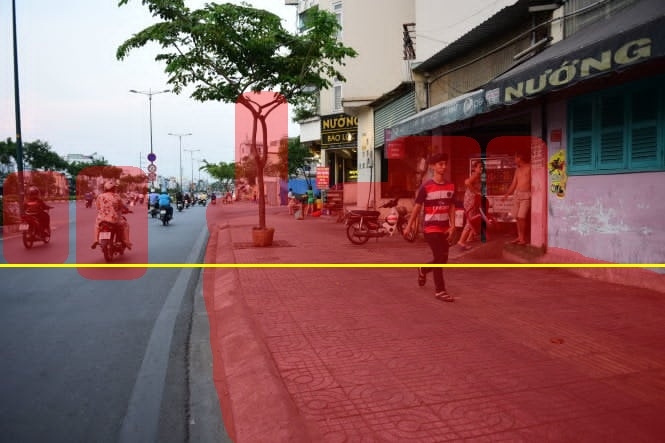

In [ ]:
from IPython.display import Image
Image(filename='/content/drive/MyDrive/Det_Seg/alert_output.jpg', width=640)

In [ ]:
import os, shutil

shutil.copy("/content/drive/MyDrive/Group_Project/runs/detect/train9/weights/best.pt",
            f"{SAVE_DIR}/detect_best.pt")
shutil.copy("/content/drive/MyDrive/Segmentation/runs/segment/train/weights/best.pt",
            f"{SAVE_DIR}/segment_best.pt")

print("Saved to:", SAVE_DIR)

Saved to: /content/drive/MyDrive/Det_Seg/save_models
